# Модуль 2. Деревья решений — кирпичик бустинга

**Интерактивная версия:** `lessons/lesson_2/web/index.html`

Дерево от А до Я на одном маленьком примере — восьми квартирах, где каждое число можно пересчитать руками:

1. Данные и «дерево глубины 0».
2. Какое число записать в лист: среднее.
3. Один вопрос: перебор порогов и выигрыш $\Delta$.
4. Выбор признака.
5. Рекурсия: всё дерево в 15 строках — и сверка с scikit-learn и `gbcourse`.
6. Прогноз как путь от корня к листу.
7. Глубина: недообучение и переобучение.
8. Дерево как функция: лесенка и прямоугольники.
9. Свойства: масштаб признака, экстраполяция, неустойчивость.
10. Мостик к бустингу: деревья на остатках.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_text

from gbcourse import RegressionTree, datasets
from gbcourse.plotting import plot_data, plot_decision_surface, plot_predict_1d, plot_tree, use_course_style
from gbcourse.style import ROLE

use_course_style()

## 1. Данные: восемь квартир

Два признака — площадь и расстояние до центра — и ответ: цена в миллионах.

In [2]:
area = np.array([30, 35, 42, 50, 62, 70, 78, 90])            # площадь, м²
dist = np.array([12, 3, 9, 4, 10, 2, 8, 3])                   # до центра, км
price = np.array([3.0, 5.0, 3.6, 5.8, 7.0, 9.6, 7.8, 10.6])   # цена, млн
X = np.c_[area, dist]
NAMES = ["площадь", "до центра"]
flats = pd.DataFrame({"площадь, м²": area, "до центра, км": dist, "цена, млн": price}, index=range(1, 9))
flats

,"площадь, м²","до центра, км","цена, млн"
1,30,12,3.0
2,35,3,5.0
3,42,9,3.6
4,50,4,5.8
5,62,10,7.0
6,70,2,9.6
7,78,8,7.8
8,90,3,10.6


Ошибку меряем суммой квадратов: $\text{SSE} = \sum_i (y_i - \hat y_i)^2$.
Дерево глубины 0 — один лист без вопросов: всем квартирам один прогноз.

In [3]:
def sse(v):
    """Ошибка листа: сумма квадратов отклонений от среднего."""
    return float(((v - v.mean()) ** 2).sum()) if len(v) else 0.0


print(f"прогноз дерева глубины 0: {price.mean():.2f} млн, SSE = {sse(price):.2f}")
assert np.isclose(price.mean(), 6.55) and np.isclose(sse(price), 51.74)

прогноз дерева глубины 0: 6.55 млн, SSE = 51.74


## 2. Какое число записать в лист

Лист выдаёт одно число $c$ на всю группу. Посмотрим на $\text{SSE}(c)$ для всех восьми квартир:
минимум — ровно в среднем.

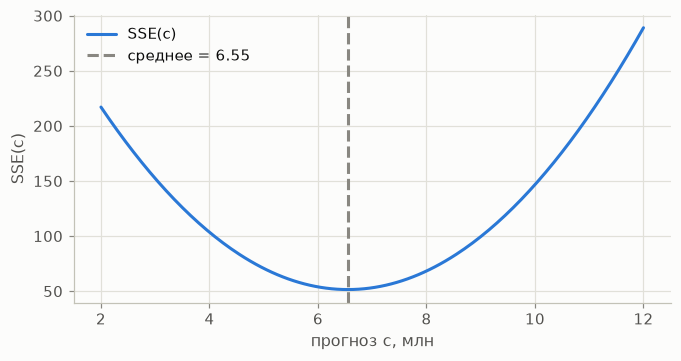

минимум кривой при c = 6.55


In [4]:
cs = np.linspace(2, 12, 201)
curve = [((price - c) ** 2).sum() for c in cs]
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(cs, curve, color=ROLE["model"], label="SSE(c)")
ax.axvline(price.mean(), color=ROLE["truth"], ls="--", label=f"среднее = {price.mean():.2f}")
ax.set(xlabel="прогноз c, млн", ylabel="SSE(c)")
ax.legend()
plt.show()
print("минимум кривой при c =", cs[int(np.argmin(curve))])

## 3. Один вопрос: перебор порогов

Вопрос «признак ≤ $t$?» делит квартиры на две группы; в каждой прогноз — своё среднее.
Пороги-кандидаты — середины между соседними значениями признака.
**Выигрыш** вопроса: $\Delta = \text{SSE}_\text{до} - \text{SSE}_\text{слева} - \text{SSE}_\text{справа}$.

In [5]:
def candidates(col, y):
    """Таблица всех порогов одного признака."""
    vals = np.unique(col)
    rows = []
    for t in (vals[:-1] + vals[1:]) / 2:
        left, right = y[col <= t], y[col > t]
        rows.append({"порог": t, "n слева": len(left), "среднее слева": left.mean(), "n справа": len(right),
                     "среднее справа": right.mean(), "SSE после": sse(left) + sse(right),
                     "выигрыш": sse(y) - sse(left) - sse(right)})
    return pd.DataFrame(rows)


by_area = candidates(area, price)
by_area.round(2)

,порог,n слева,среднее слева,n справа,среднее справа,SSE после,выигрыш
0,32.5,1,3.00,7,7.06,37.34,14.40
1,38.5,2,4.00,6,7.40,34.40,17.34
2,46.0,3,3.87,5,8.16,17.18,34.56
3,56.0,4,4.35,4,8.75,13.02,38.72
4,66.0,5,4.88,3,9.33,14.55,37.19
5,74.0,6,5.67,2,9.20,33.01,18.73
6,84.0,7,5.97,1,10.60,32.99,18.75


In [6]:
best_area = by_area.loc[by_area["выигрыш"].idxmax()]
print(f"лучший порог по площади: {best_area['порог']}, выигрыш {best_area['выигрыш']:.2f}")
assert best_area["порог"] == 56 and np.isclose(best_area["выигрыш"], 38.72)

лучший порог по площади: 56.0, выигрыш 38.72


## 4. Какой признак выбрать

То же самое — для расстояния до центра; признаки сравниваются по выигрышу.

In [7]:
by_dist = candidates(dist, price)
best_dist = by_dist.loc[by_dist["выигрыш"].idxmax()]
pd.DataFrame({"площадь": best_area, "до центра": best_dist}).T.round(2)

,порог,n слева,среднее слева,n справа,среднее справа,SSE после,выигрыш
площадь,56.0,4.0,4.35,4.0,8.75,13.02,38.72
до центра,8.5,5.0,7.76,3.0,4.53,32.22,19.52


Побеждает «площадь ≤ 56»: 38.72 против 19.52. Единицы измерения (метры, километры) роли не играют —
сравнивается уменьшение ошибки.

## 5. Рекурсия: всё дерево

С каждой из двух групп делаем то же самое, что со всеми данными.

In [8]:
def best_split(X, y):
    """Лучший вопрос узла: (выигрыш, номер признака, порог)."""
    best = (0.0, None, None)
    for j in range(X.shape[1]):
        vals = np.unique(X[:, j])
        for t in (vals[:-1] + vals[1:]) / 2:
            left = X[:, j] <= t
            gain = sse(y) - sse(y[left]) - sse(y[~left])
            if gain > best[0] + 1e-12:
                best = (gain, j, t)
    return best


def grow(X, y, depth=0, max_depth=2, log=None):
    """Рекурсивный рост; печатает дерево и возвращает суммарную SSE листьев."""
    pad = "    " * depth
    gain, j, t = best_split(X, y)
    if depth == max_depth or j is None:
        print(f"{pad}лист: {y.mean():.2f} (объектов {len(y)}, SSE {sse(y):.2f})")
        return sse(y)
    print(f"{pad}{NAMES[j]} <= {t}?  (выигрыш {gain:.2f})")
    left = X[:, j] <= t
    return grow(X[left], y[left], depth + 1, max_depth) + grow(X[~left], y[~left], depth + 1, max_depth)


total = grow(X, price)
print(f"\nSSE дерева глубины 2: {total:.2f}")
assert np.isclose(total, 1.32)

площадь <= 56.0?  (выигрыш 38.72)
    до центра <= 6.5?  (выигрыш 4.41)
        лист: 5.40 (объектов 2, SSE 0.32)
        лист: 3.30 (объектов 2, SSE 0.18)
    до центра <= 5.5?  (выигрыш 7.29)
        лист: 10.10 (объектов 2, SSE 0.50)
        лист: 7.40 (объектов 2, SSE 0.32)

SSE дерева глубины 2: 1.32


Путь ошибки: **51.74 → 13.02 → 1.32 → 0**. Сверим с библиотеками.

In [9]:
for d in (1, 2, 3):
    sk = DecisionTreeRegressor(max_depth=d).fit(X, price)
    ours = RegressionTree(max_depth=d).fit(X, -price)   # g = −y, h = 1 → в листьях средние y
    err = ((price - sk.predict(X)) ** 2).sum()
    print(f"глубина {d}: листьев {sk.get_n_leaves()}, SSE {err:5.2f}, "
          f"расхождение sklearn и gbcourse {np.abs(sk.predict(X) - ours.predict(X)).max():.1e}")
sk2 = DecisionTreeRegressor(max_depth=2).fit(X, price)
print()
print(export_text(sk2, feature_names=["area", "dist"]))

глубина 1: листьев 2, SSE 13.02, расхождение sklearn и gbcourse 0.0e+00
глубина 2: листьев 4, SSE  1.32, расхождение sklearn и gbcourse 0.0e+00
глубина 3: листьев 8, SSE  0.00, расхождение sklearn и gbcourse 0.0e+00

|--- area <= 56.00
|   |--- dist <= 6.50
|   |   |--- value: [5.40]
|   |--- dist >  6.50
|   |   |--- value: [3.30]
|--- area >  56.00
|   |--- dist <= 5.50
|   |   |--- value: [10.10]
|   |--- dist >  5.50
|   |   |--- value: [7.40]



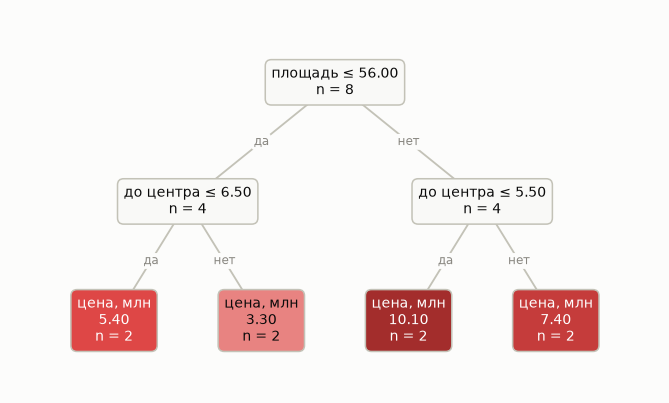

In [10]:
ours2 = RegressionTree(max_depth=2).fit(X, -price)
plot_tree(ours2, feature_names=NAMES, value_label="цена, млн")
plt.show()

## 6. Прогноз — путь по дереву

Новая квартира: 60 м², 4 км от центра.

In [11]:
x_new = np.array([60.0, 4.0])
path = ours2.decision_path(x_new)
for nid in path:
    nd = ours2.nodes[nid]
    if nd.is_leaf:
        print(f"лист #{nid}: прогноз = {nd.value:.2f} млн")
    else:
        side = "да → налево" if x_new[nd.feature] <= nd.threshold else "нет → направо"
        print(f"узел #{nid}: {NAMES[nd.feature]} ≤ {nd.threshold}?  у нас {x_new[nd.feature]:g} — {side}")
assert np.isclose(ours2.predict(x_new[None, :])[0], 10.1)

узел #0: площадь ≤ 56.0?  у нас 60 — нет → направо
узел #2: до центра ≤ 5.5?  у нас 4 — да → налево
лист #5: прогноз = 10.10 млн


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


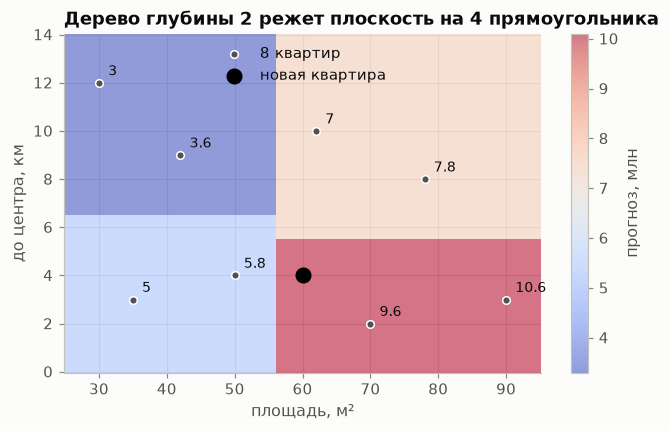

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
grid_a, grid_d = np.meshgrid(np.linspace(25, 95, 200), np.linspace(0, 14, 200))
pred = sk2.predict(np.c_[grid_a.ravel(), grid_d.ravel()]).reshape(grid_a.shape)
im = ax.pcolormesh(grid_a, grid_d, pred, cmap="coolwarm", alpha=0.55, shading="auto")
ax.scatter(area, dist, color=ROLE["data"], edgecolor="white", zorder=3, label="8 квартир")
ax.scatter(*x_new, color="black", s=90, zorder=4, label="новая квартира")
for a, d, p in zip(area, dist, price):
    ax.annotate(f"{p:g}", (a, d), textcoords="offset points", xytext=(6, 5), fontsize=9)
ax.set(xlabel="площадь, м²", ylabel="до центра, км", title="Дерево глубины 2 режет плоскость на 4 прямоугольника")
fig.colorbar(im, label="прогноз, млн")
ax.legend(loc="upper center")
plt.show()

## 7. Глубина: недообучение и переобучение

60 точек зависимости с шумом и 400 новых точек из той же зависимости.

In [13]:
Xs, ys = datasets.regression_1d(kind="sine", n=60, noise=0.35, seed=3)
Xn, yn = datasets.regression_1d(kind="sine", n=400, noise=0.35, seed=1003)
rows = []
for d in range(11):
    if d == 0:
        p_tr, p_new, leaves = np.full(len(ys), ys.mean()), np.full(len(yn), ys.mean()), 1
    else:
        t = DecisionTreeRegressor(max_depth=d).fit(Xs, ys)
        p_tr, p_new, leaves = t.predict(Xs), t.predict(Xn), t.get_n_leaves()
    rows.append({"глубина": d, "листьев": leaves, "MSE обучение": np.mean((ys - p_tr) ** 2), "MSE новые данные": np.mean((yn - p_new) ** 2)})
curve = pd.DataFrame(rows).set_index("глубина")
curve.round(4)

,листьев,MSE обучение,MSE новые данные
глубина,,,
0,1,0.6662,0.6187
1,2,0.4132,0.6790
2,4,0.1719,0.2487
3,7,0.1472,0.2868
4,11,0.0968,0.2619
5,17,0.0752,0.2475
6,25,0.0524,0.2487
7,38,0.0276,0.2606
8,48,0.0034,0.2993


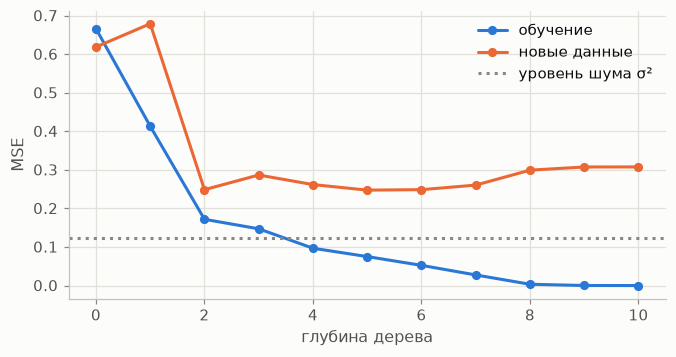

In [14]:
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(curve.index, curve["MSE обучение"], "o-", color=ROLE["train"], label="обучение")
ax.plot(curve.index, curve["MSE новые данные"], "o-", color=ROLE["valid"], label="новые данные")
ax.axhline(0.35 ** 2, color=ROLE["truth"], ls=":", label="уровень шума σ²")
ax.set(xlabel="глубина дерева", ylabel="MSE")
ax.legend()
plt.show()

На обучении ошибка падает до нуля; на новых данных — падает до глубины 2 и дальше не улучшается,
а к глубине 10 растёт: дерево запоминает шум.

## 8. Дерево как функция

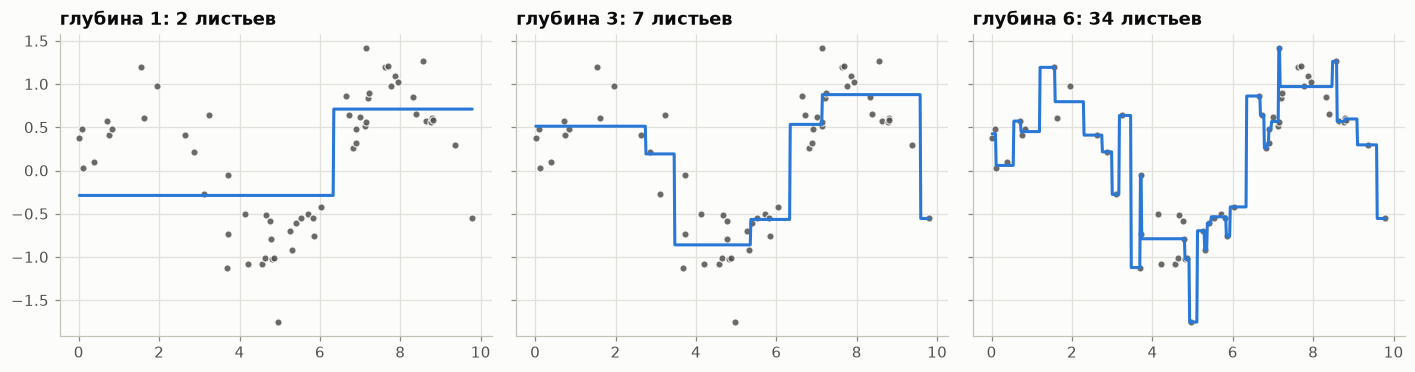

In [15]:
X1, y1 = datasets.regression_1d(kind="sine", n=60, noise=0.25, seed=3)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, d in zip(axes, (1, 3, 6)):
    t = RegressionTree(max_depth=d).fit(X1, -y1)
    plot_data(ax, X1, y1, label=None)
    plot_predict_1d(ax, t.predict, X1, label=None)
    ax.set_title(f"глубина {d}: {t.n_leaves} листьев")
plt.tight_layout()
plt.show()

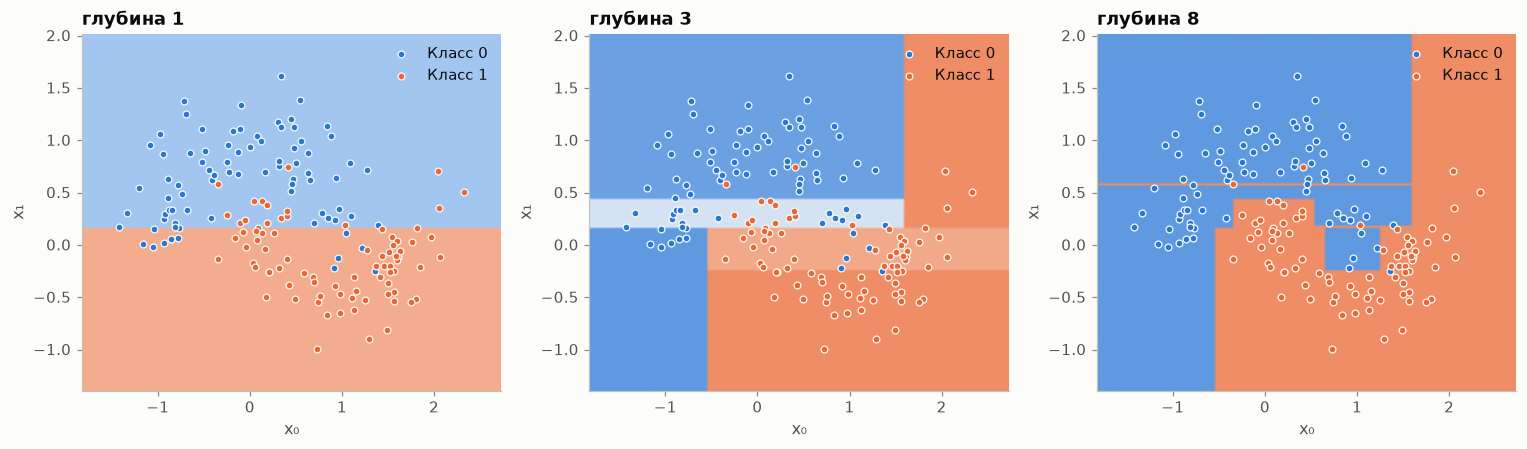

In [16]:
Xc, yc = datasets.classification_2d(kind="moons", n=160, noise=0.25, seed=4)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, d in zip(axes, (1, 3, 8)):
    clf = DecisionTreeClassifier(max_depth=d, random_state=0).fit(Xc, yc)
    plot_decision_surface(ax, clf.predict_proba, Xc, yc, title=f"глубина {d}", show_contour=False)
plt.tight_layout()
plt.show()

## 9. Свойства дерева

**Масштаб и форма шкалы признака не важны.** Заменим $x$ на $x^3$: группы объектов и прогнозы те же.

In [17]:
Xp, yp = datasets.regression_1d(kind="sine", n=40, noise=0.25, seed=7, x_min=0.5, x_max=10)
a = DecisionTreeRegressor(max_depth=2).fit(Xp, yp)
b = DecisionTreeRegressor(max_depth=2).fit(Xp ** 3, yp)
print("макс. разница прогнозов на обучающих точках:", np.abs(a.predict(Xp) - b.predict(Xp ** 3)).max())
print("пороги по x:  ", np.sort(a.tree_.threshold[a.tree_.feature >= 0]).round(3))
print("пороги по x³: ", np.sort(b.tree_.threshold[b.tree_.feature >= 0]).round(3))

макс. разница прогнозов на обучающих точках: 0.0
пороги по x:   [2.815 3.107 6.083]
пороги по x³:  [ 22.328  30.214 226.97 ]


**Дерево не экстраполирует.** Обучаем на $x \in [2, 8]$ и спрашиваем про $x = 11$.

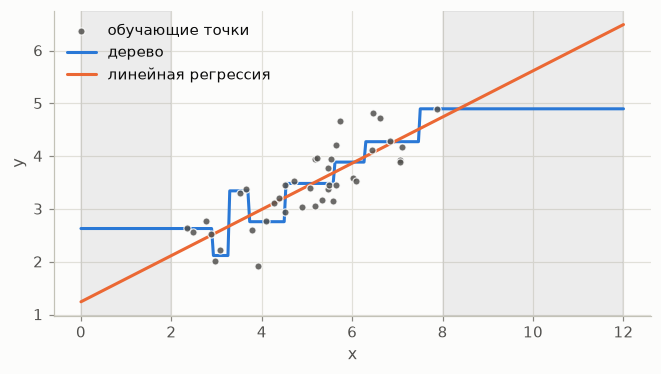

x =  5.0: дерево 3.484, прямая 3.430
x =  9.0: дерево 4.898, прямая 5.181
x = 11.0: дерево 4.898, прямая 6.056


In [18]:
Xe, ye = datasets.regression_1d(kind="linear", n=40, noise=0.4, seed=11, x_min=2, x_max=8)
tree_e = DecisionTreeRegressor(max_depth=3).fit(Xe, ye)
line_e = LinearRegression().fit(Xe, ye)
grid = np.linspace(0, 12, 300)[:, None]
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.axvspan(0, 2, color="gray", alpha=0.12)
ax.axvspan(8, 12, color="gray", alpha=0.12)
plot_data(ax, Xe, ye, label="обучающие точки")
ax.plot(grid, tree_e.predict(grid), color=ROLE["model"], label="дерево")
ax.plot(grid, line_e.predict(grid), color=ROLE["tree"], label="линейная регрессия")
ax.set(xlabel="x", ylabel="y")
ax.legend()
plt.show()
for x0 in (5.0, 9.0, 11.0):
    print(f"x = {x0:4.1f}: дерево {tree_e.predict([[x0]])[0]:.3f}, прямая {line_e.predict([[x0]])[0]:.3f}")

**Дерево неустойчиво.** Семь выборок из одной и той же зависимости — семь разных деревьев;
их среднее гораздо спокойнее (это идея ансамблей, модуль 3).

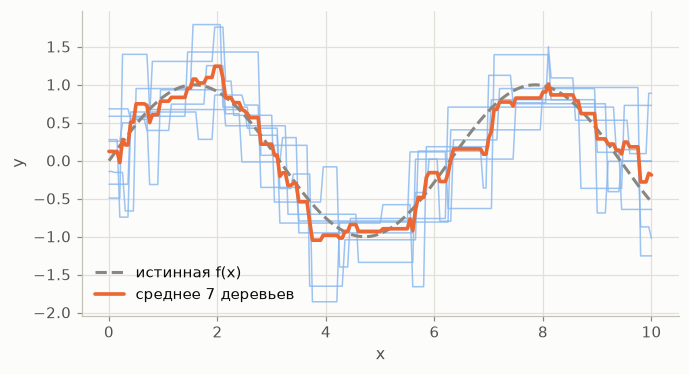

пороги корня: [3.28 6.98 2.77 3.03 2.43 3.1  3.11]
средняя ошибка одного дерева относительно f(x): 0.189; ошибка среднего: 0.029


In [19]:
grid = np.linspace(0, 10, 201)[:, None]
preds, roots = [], []
for seed in range(101, 108):
    Xi, yi = datasets.regression_1d(kind="sine", n=40, noise=0.45, seed=seed)
    t = DecisionTreeRegressor(max_depth=4).fit(Xi, yi)
    preds.append(t.predict(grid))
    roots.append(t.tree_.threshold[0])
preds = np.array(preds)
fig, ax = plt.subplots(figsize=(7, 3.6))
for p in preds:
    ax.plot(grid, p, color=ROLE["model_prev"], lw=1, alpha=0.8)
ax.plot(grid, np.sin(grid), color=ROLE["truth"], ls="--", label="истинная f(x)")
ax.plot(grid, preds.mean(0), color=ROLE["tree"], lw=2.4, label="среднее 7 деревьев")
ax.set(xlabel="x", ylabel="y")
ax.legend()
plt.show()
print("пороги корня:", np.round(roots, 2))
print(f"средняя ошибка одного дерева относительно f(x): {np.mean((preds - np.sin(grid).T) ** 2):.3f}; "
      f"ошибка среднего: {np.mean((preds.mean(0) - np.sin(grid).ravel()) ** 2):.3f}")

## 10. Мостик к бустингу

Много маленьких деревьев, каждое учится на **остатках** предыдущих (подробно — модуль 4).

In [20]:
Xb, yb = datasets.regression_1d(kind="sine", n=60, noise=0.25, seed=3)
stump = DecisionTreeRegressor(max_depth=1).fit(Xb, yb)
print(f"один пень: MSE = {np.mean((yb - stump.predict(Xb)) ** 2):.4f}")
nu, F = 0.5, np.full(len(yb), yb.mean())
for m in range(1, 41):
    residual = yb - F                                        # что ещё не объяснено
    tree = DecisionTreeRegressor(max_depth=1).fit(Xb, residual)
    F += nu * tree.predict(Xb)                               # добавляем долю нового пня
    if m in (1, 5, 10, 20, 40):
        print(f"сумма {m:2d} пней: MSE = {np.mean((yb - F) ** 2):.4f}")

один пень: MSE = 0.3472
сумма  1 пней: MSE = 0.4078
сумма  5 пней: MSE = 0.2045
сумма 10 пней: MSE = 0.1275
сумма 20 пней: MSE = 0.0838
сумма 40 пней: MSE = 0.0620


## Упражнения

1. Для корня и признака «до центра» посчитайте вручную выигрыш порога 6 и сверьте с таблицей `by_dist`.
2. Какой прогноз дерево глубины 2 даст квартире 200 м² в 1 км от центра? Почему он неправдоподобен?
3. Сколько листьев у дерева глубины 6 на 60 точках из п. 8? Почему меньше 64?
4. Умножьте площадь на 10 000 (см²) и обучите дерево глубины 2. Что изменилось?
5. Пометьте квартиры №2, 4, 6, 7, 8 классом 1, остальные — 0. Посчитайте индекс Джини до и после
   вопроса «до центра ≤ 6.5».

Решения: `python lessons/lesson_2/exercises/solutions.py`.